<a href="https://colab.research.google.com/github/yatharthchopra2424/Ai-Learn/blob/main/Linear_Regression_Model(2301420022).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [145]:
# importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [146]:
df = pd.read_csv('Placement_Data.csv')

# **Data Overview**

In [147]:
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [148]:
# Removing the sl_no as it plays no importance for model training
df.drop('sl_no', inplace = True, axis=1)

In [149]:
# Shape of dataset
df.shape

(215, 14)

In [150]:
# checking the information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          215 non-null    object 
 1   ssc_p           215 non-null    float64
 2   ssc_b           215 non-null    object 
 3   hsc_p           215 non-null    float64
 4   hsc_b           215 non-null    object 
 5   hsc_s           215 non-null    object 
 6   degree_p        215 non-null    float64
 7   degree_t        215 non-null    object 
 8   workex          215 non-null    object 
 9   etest_p         215 non-null    float64
 10  specialisation  215 non-null    object 
 11  mba_p           215 non-null    float64
 12  status          215 non-null    object 
 13  salary          148 non-null    float64
dtypes: float64(6), object(8)
memory usage: 23.6+ KB


In [151]:
# checking the basic summary
df.describe()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


Insights:


1.   Avg. passing marks of ssc is: 67.3%
2.   Avg. passing marks of hsc is: 66.3%
3.   Avg. passing marks of degree is: 66.3%
4.   Avg. passing marks of mba is: 62.2%



# **Data Cleaning**

In [152]:
df.sample(3)

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
172,M,73.0,Others,58.0,Others,Commerce,56.0,Comm&Mgmt,No,84.0,Mkt&HR,52.64,Placed,300000.0
125,F,84.0,Central,73.0,Central,Commerce,73.0,Comm&Mgmt,No,75.0,Mkt&Fin,73.33,Placed,350000.0
131,F,74.9,Others,57.0,Others,Science,62.0,Others,Yes,80.0,Mkt&Fin,60.78,Placed,360000.0


In [153]:
# only column with null value if > 1
null_counts = df.isnull().sum()
print(null_counts[null_counts > 1])

salary    67
dtype: int64


In [154]:
# Fill the null value in salary column with 0
df['salary'].fillna(0, inplace=True)

In [155]:
# We need to explore the status column
df['status'].value_counts()

,count
status,
Placed,148
Not Placed,67


It can be seen that where even status is not placed, salary is 0

In [156]:
# Checking for duplicate values
df.duplicated().sum()

np.int64(0)

Now, this is obvious that Not placed students have no salary. So, let's drop those values right now and work on data only where data exist.

# **Analysis of why students placed? and why not?**

***Placed Students***

In [157]:
df_placed = df[df['status'] == 'Placed']
df_unplaced = df[df['status'] == 'Not Placed']
df_placed.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
7,M,82.00,Central,64.00,Central,Science,66.00,Sci&Tech,Yes,67.0,Mkt&Fin,62.14,Placed,252000.0


In [158]:
df_placed.describe()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000
mean,71.721486,69.926554,68.740541,73.238041,62.579392,288655.405405
std,8.715445,9.329268,6.518087,13.729333,5.884583,93457.452420
min,49.000000,50.830000,56.000000,50.000000,52.380000,200000.000000
25%,65.000000,63.000000,65.000000,60.000000,57.772500,240000.000000
50%,72.500000,68.000000,68.000000,72.000000,62.245000,265000.000000
75%,78.125000,75.250000,72.422500,85.000000,66.760000,300000.000000
max,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [159]:
df_unplaced.describe()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,67.000000,67.000000,67.000000,67.000000,67.000000,67.0
mean,57.544030,58.395522,61.134179,69.587910,61.612836,0.0
std,8.394246,9.914090,6.365825,11.930687,5.705689,0.0
min,40.890000,37.000000,50.000000,50.000000,51.210000,0.0
25%,52.000000,51.000000,57.000000,60.000000,58.480000,0.0
50%,56.280000,60.330000,61.000000,67.000000,60.690000,0.0
75%,63.000000,64.000000,65.000000,76.500000,65.405000,0.0
max,77.800000,82.000000,79.000000,97.000000,75.710000,0.0


Insights:


1.   Avg. difference betwee ssc marks is: ~15%
2.   Avg. difference betwee hsc marks is: ~10%



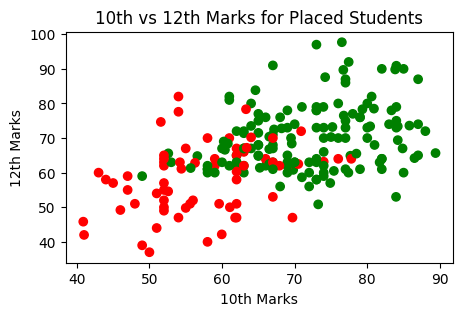

In [160]:
# Scatter plot between 10th and 12th marks
plt.figure(figsize=(5, 3))
plt.scatter(df['ssc_p'], df['hsc_p'], c=df['status'].map({'Placed': 'green', 'Not Placed': 'red'}))
plt.xlabel('10th Marks')
plt.ylabel('12th Marks')
plt.title('10th vs 12th Marks for Placed Students')
plt.show()

Mostly students who got places have, more than 70% of marks in both 10th and 12th standard

<Axes: >

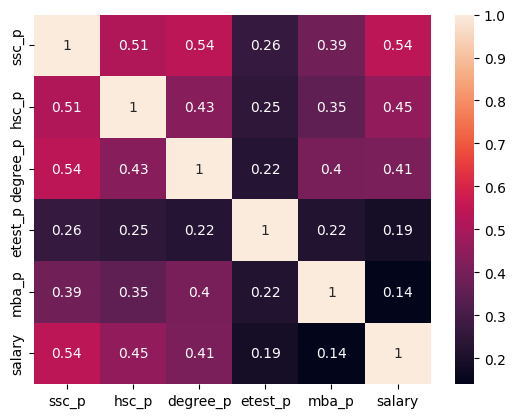

In [161]:
# checking the correlation
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True)

<Axes: xlabel='salary', ylabel='Count'>

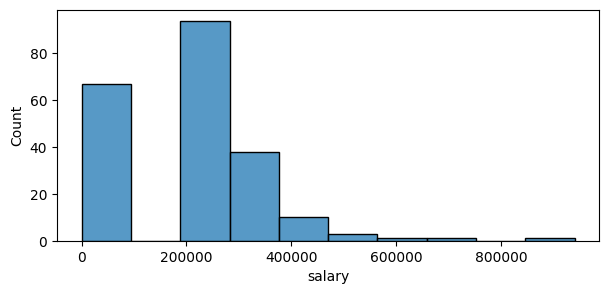

In [162]:
plt.figure(figsize=(7, 3))
sns.histplot(df['salary'])

# **Outlier detection**

<Axes: ylabel='salary'>

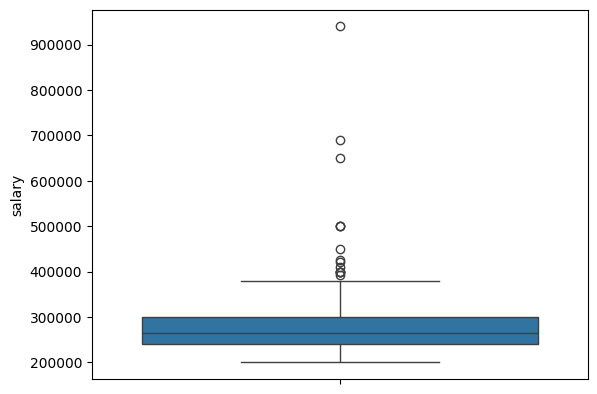

In [163]:
sns.boxplot(df_placed['salary'])

***Using the IQR Method***

In [164]:
# using IQR Method
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['salary'] < lower_bound) | (df['salary'] > upper_bound)]

cleaned_data = df[(df['salary'] >= lower_bound) & (df['salary'] <= upper_bound)]

In [165]:
cleaned_data.shape

(214, 14)

<Axes: ylabel='salary'>

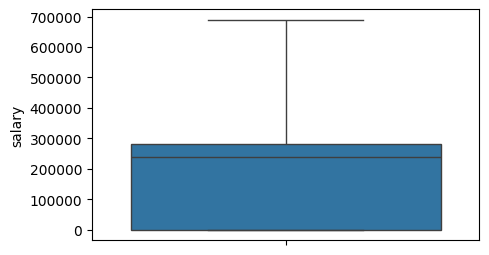

In [166]:
plt.figure(figsize=(5, 3))
sns.boxplot(cleaned_data['salary'])

In [167]:
cleaned_data.sample(4)

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
56,M,63.0,Others,71.4,Others,Commerce,61.4,Comm&Mgmt,No,68.0,Mkt&Fin,66.88,Placed,240000.0
138,F,82.0,Others,64.0,Others,Science,73.0,Sci&Tech,Yes,96.0,Mkt&Fin,71.77,Placed,250000.0
43,M,87.0,Others,87.0,Others,Commerce,68.0,Comm&Mgmt,No,95.0,Mkt&HR,62.90,Placed,300000.0
48,M,63.0,Others,62.0,Others,Commerce,68.0,Comm&Mgmt,No,64.0,Mkt&Fin,62.46,Placed,250000.0


In [168]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214 entries, 0 to 214
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          214 non-null    object 
 1   ssc_p           214 non-null    float64
 2   ssc_b           214 non-null    object 
 3   hsc_p           214 non-null    float64
 4   hsc_b           214 non-null    object 
 5   hsc_s           214 non-null    object 
 6   degree_p        214 non-null    float64
 7   degree_t        214 non-null    object 
 8   workex          214 non-null    object 
 9   etest_p         214 non-null    float64
 10  specialisation  214 non-null    object 
 11  mba_p           214 non-null    float64
 12  status          214 non-null    object 
 13  salary          214 non-null    float64
dtypes: float64(6), object(8)
memory usage: 25.1+ KB


In [169]:
# Checking uniqe in object column
for col in cleaned_data.columns:
    if cleaned_data[col].dtype == 'object':
        print(f"{col}: {cleaned_data[col].unique()}")

gender: ['M' 'F']
ssc_b: ['Others' 'Central']
hsc_b: ['Others' 'Central']
hsc_s: ['Commerce' 'Science' 'Arts']
degree_t: ['Sci&Tech' 'Comm&Mgmt' 'Others']
workex: ['No' 'Yes']
specialisation: ['Mkt&HR' 'Mkt&Fin']
status: ['Placed' 'Not Placed']


Since, we have less number of uniqe in column so will go for Label Encoding

# **Label Encoding**

In [170]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in cleaned_data.columns:
    if cleaned_data[col].dtype == 'object':
        cleaned_data[col] = le.fit_transform(cleaned_data[col])

In [171]:
cleaned_data.sample(5)

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
158,1,67.0,1,63.0,1,2,64.0,2,0,60.00,0,61.87,0,0.0
62,0,86.5,1,64.2,1,2,67.4,2,0,59.00,0,59.69,1,240000.0
38,0,73.0,1,58.0,1,2,66.0,0,0,53.70,1,56.86,1,240000.0
170,0,63.4,1,67.2,1,1,60.0,0,0,58.06,1,69.28,0,0.0
44,0,77.0,1,73.0,1,1,81.0,0,1,89.00,0,69.70,1,200000.0


# **Model Training - Linear Regression**

In [172]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [173]:
# Splitting the data
X = cleaned_data.drop('salary', axis=1)
y = cleaned_data['salary']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [174]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [175]:
# model training
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [176]:
# Prediction
y_pred = model.predict(x_test)

In [177]:
# Checking the mse, rmse and r2
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Squared Error: 2343200610.181928
Root Mean Squared Error: 48406.61742140147
R-squared: 0.8740998137836391


# **Checking for Overfitting/ Underfitting**

In [178]:
r2_train = r2_score(y_train, model.predict(x_train))
r2_test  = r2_score(y_test, model.predict(x_test))

print("Train R²:", r2_train)
print("Test R²:", r2_test)

Train R²: 0.8229051029420553
Test R²: 0.8740998137836391


*This seems good, model is evenly fitted.*

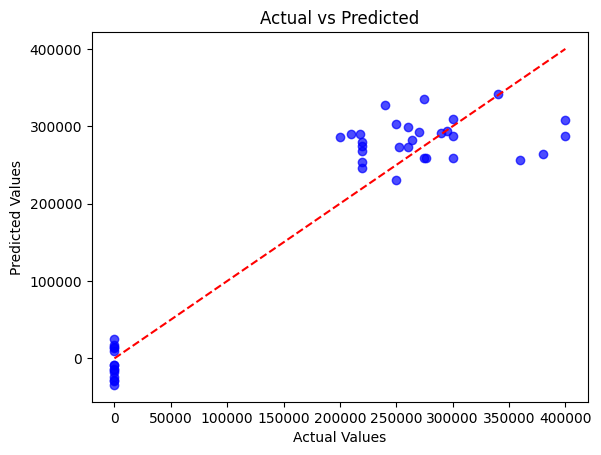

In [179]:
import matplotlib.pyplot as plt

y_pred = model.predict(x_test)

plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linestyle="--")  # perfect fit line
plt.show()


In [180]:
import joblib

# Save the model to a file
filename = 'linear_regression_model.joblib'
joblib.dump(model, filename)

print(f"Model saved to {filename}")

Model saved to linear_regression_model.joblib


**Explanation:**

This code imports the necessary libraries for data manipulation (`pandas`, `numpy`), data visualization (`matplotlib.pyplot`, `seaborn`), and suppressing warnings (`warnings`). These libraries are commonly used in data analysis and machine learning workflows.

In [181]:
# importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**Explanation:**

This code reads the `Placement_Data.csv` file into a pandas DataFrame named `df`. This is the first step in loading the data for analysis.

In [182]:
df = pd.read_csv('Placement_Data.csv')

# **Data Overview**

**Explanation:**

This code displays the first 5 rows of the DataFrame `df` using the `.head()` method. This is useful for getting a quick look at the structure and content of the data.

In [183]:
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


**Explanation:**

This code removes the 'sl_no' column from the DataFrame `df` in-place (`inplace=True`) along the column axis (`axis=1`). The 'sl_no' column is likely a serial number and not relevant for model training.

In [184]:
# Removing the sl_no as it plays no importance for model training
df.drop('sl_no', inplace = True, axis=1)

**Explanation:**

This code prints the shape of the DataFrame `df` using the `.shape` attribute. The output `(215, 14)` indicates that the DataFrame has 215 rows and 14 columns.

In [185]:
# Shape of dataset
df.shape

(215, 14)

**Explanation:**

This code prints a concise summary of the DataFrame `df` using the `.info()` method. It shows the column names, non-null counts, and data types, which helps in understanding the data structure and identifying missing values.

In [186]:
# checking the information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          215 non-null    object 
 1   ssc_p           215 non-null    float64
 2   ssc_b           215 non-null    object 
 3   hsc_p           215 non-null    float64
 4   hsc_b           215 non-null    object 
 5   hsc_s           215 non-null    object 
 6   degree_p        215 non-null    float64
 7   degree_t        215 non-null    object 
 8   workex          215 non-null    object 
 9   etest_p         215 non-null    float64
 10  specialisation  215 non-null    object 
 11  mba_p           215 non-null    float64
 12  status          215 non-null    object 
 13  salary          148 non-null    float64
dtypes: float64(6), object(8)
memory usage: 23.6+ KB


**Explanation:**

This code prints the descriptive statistics of the numerical columns in the DataFrame `df` using the `.describe()` method. It provides insights into the central tendency, dispersion, and shape of the distributions, such as mean, standard deviation, minimum, maximum, and quartiles.

In [187]:
# checking the basic summary
df.describe()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


Insights:

1. Avg. passing marks of ssc is: 67.3%
2. Avg. passing marks of hsc is: 66.3%
3. Avg. passing marks of degree is: 66.3%
4. Avg. passing marks of mba is: 62.2%



**Explanation:**

This markdown cell summarizes the average passing marks for different academic stages based on the `df.describe()` output.

# **Data Cleaning**

**Explanation:**

This markdown cell introduces the data cleaning section of the notebook.

**Explanation:**

This code displays a random sample of 3 rows from the DataFrame `df` using the `.sample(3)` method. This is another way to quickly inspect the data and get a feel for its contents.

In [188]:
df.sample(3)

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
121,F,64.0,Central,67.00,Others,Science,69.6,Sci&Tech,Yes,55.67,Mkt&HR,71.49,Placed,250000.0
51,M,54.4,Central,61.12,Central,Commerce,56.2,Comm&Mgmt,No,67.00,Mkt&HR,62.65,Not Placed,NaN
18,F,63.0,Central,66.00,Central,Commerce,64.0,Comm&Mgmt,No,68.00,Mkt&HR,64.08,Not Placed,NaN


**Explanation:**

This code calculates the number of null values in each column of the DataFrame `df` using `.isnull().sum()`. It then filters and prints only those columns that have more than 1 null value. This helps in identifying columns with significant missing data.

In [189]:
# only column with null value if > 1
null_counts = df.isnull().sum()
print(null_counts[null_counts > 1])

salary    67
dtype: int64


**Explanation:**

This code imports the necessary libraries for data manipulation (`pandas`, `numpy`), data visualization (`matplotlib.pyplot`, `seaborn`), and suppressing warnings (`warnings`). These libraries are commonly used in data analysis and machine learning workflows.

In [217]:
# importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**Explanation:**

This code reads the `Placement_Data.csv` file into a pandas DataFrame named `df`. This is the first step in loading the data for analysis.

In [218]:
df = pd.read_csv('Placement_Data.csv')

# **Data Overview**

**Explanation:**

This code displays the first 5 rows of the DataFrame `df` using the `.head()` method. This is useful for getting a quick look at the structure and content of the data.

In [219]:
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


**Explanation:**

This code removes the 'sl_no' column from the DataFrame `df` in-place (`inplace=True`) along the column axis (`axis=1`). The 'sl_no' column is likely a serial number and not relevant for model training.

In [220]:
# Removing the sl_no as it plays no importance for model training
df.drop('sl_no', inplace = True, axis=1)

**Explanation:**

This code prints the shape of the DataFrame `df` using the `.shape` attribute. The output `(215, 14)` indicates that the DataFrame has 215 rows and 14 columns.

In [221]:
# Shape of dataset
df.shape

(215, 14)

**Explanation:**

This code prints a concise summary of the DataFrame `df` using the `.info()` method. It shows the column names, non-null counts, and data types, which helps in understanding the data structure and identifying missing values.

In [222]:
# checking the information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          215 non-null    object 
 1   ssc_p           215 non-null    float64
 2   ssc_b           215 non-null    object 
 3   hsc_p           215 non-null    float64
 4   hsc_b           215 non-null    object 
 5   hsc_s           215 non-null    object 
 6   degree_p        215 non-null    float64
 7   degree_t        215 non-null    object 
 8   workex          215 non-null    object 
 9   etest_p         215 non-null    float64
 10  specialisation  215 non-null    object 
 11  mba_p           215 non-null    float64
 12  status          215 non-null    object 
 13  salary          148 non-null    float64
dtypes: float64(6), object(8)
memory usage: 23.6+ KB


**Explanation:**

This code prints the descriptive statistics of the numerical columns in the DataFrame `df` using the `.describe()` method. It provides insights into the central tendency, dispersion, and shape of the distributions, such as mean, standard deviation, minimum, maximum, and quartiles.

In [223]:
# checking the basic summary
df.describe()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


Insights:

1. Avg. passing marks of ssc is: 67.3%
2. Avg. passing marks of hsc is: 66.3%
3. Avg. passing marks of degree is: 66.3%
4. Avg. passing marks of mba is: 62.2%




**Explanation:**

This markdown cell summarizes the average passing marks for different academic stages based on the `df.describe()` output.

# **Data Cleaning**

**Explanation:**

This markdown cell introduces the data cleaning section of the notebook.

**Explanation:**

This code displays a random sample of 3 rows from the DataFrame `df` using the `.sample(3)` method. This is another way to quickly inspect the data and get a feel for its contents.

In [224]:
df.sample(3)

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
54,F,74.0,Central,60.0,Others,Science,69.0,Comm&Mgmt,No,78.0,Mkt&HR,65.56,Placed,216000.0
210,M,80.6,Others,82.0,Others,Commerce,77.6,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
133,M,73.0,Central,64.0,Others,Commerce,77.0,Comm&Mgmt,Yes,65.0,Mkt&HR,60.98,Placed,250000.0


**Explanation:**

This code calculates the number of null values in each column of the DataFrame `df` using `.isnull().sum()`. It then filters and prints only those columns that have more than 1 null value. This helps in identifying columns with significant missing data.

In [225]:
# only column with null value if > 1
null_counts = df.isnull().sum()
print(null_counts[null_counts > 1])

salary    67
dtype: int64


**Explanation:**

This code fills the null values in the 'salary' column of the DataFrame `df` with 0 using the `.fillna(0, inplace=True)` method. This is a way to handle missing values, assuming that a missing salary implies no salary (for unplaced students).

In [226]:
# Fill the null value in salary column with 0
df['salary'].fillna(0, inplace=True)

**Explanation:**

This code counts the occurrences of each unique value in the 'status' column of the DataFrame `df` using the `.value_counts()` method. This shows the distribution of 'Placed' and 'Not Placed' students in the dataset.

In [227]:
# We need to explore the status column
df['status'].value_counts()

,count
status,
Placed,148
Not Placed,67


It can be seen that where even status is not placed, salary is 0

**Explanation:**

This markdown cell observes that students with 'Not Placed' status have a salary of 0, which aligns with the previous data cleaning step.

**Explanation:**

This code checks for duplicate rows in the DataFrame `df` using the `.duplicated().sum()` method. The output of 0 indicates that there are no duplicate rows in the dataset.

In [228]:
# Checking for duplicate values
df.duplicated().sum()

np.int64(0)

Now, this is obvious that Not placed students have no salary. So, let's drop those values right now and work on data only where data exist.

**Explanation:**

This markdown cell indicates the decision to focus the analysis on placed students, as the goal is to understand factors contributing to placement.

# **Analysis of why students placed? and why not?**

**Explanation:**

This markdown cell introduces the section for analyzing the factors influencing student placement.

***Placed Students***

**Explanation:**

This markdown cell specifically focuses on the analysis of students who were placed.

**Explanation:**

This code creates two new DataFrames: `df_placed` containing rows where the 'status' is 'Placed', and `df_unplaced` containing rows where the 'status' is 'Not Placed'. It then displays the first 5 rows of the `df_placed` DataFrame.

In [229]:
df_placed = df[df['status'] == 'Placed']
df_unplaced = df[df['status'] == 'Not Placed']
df_placed.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
7,M,82.00,Central,64.00,Central,Science,66.00,Sci&Tech,Yes,67.0,Mkt&Fin,62.14,Placed,252000.0


**Explanation:**

This code provides descriptive statistics for the numerical columns of the `df_placed` DataFrame. This helps in understanding the characteristics of students who were placed.

In [230]:
df_placed.describe()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000
mean,71.721486,69.926554,68.740541,73.238041,62.579392,288655.405405
std,8.715445,9.329268,6.518087,13.729333,5.884583,93457.452420
min,49.000000,50.830000,56.000000,50.000000,52.380000,200000.000000
25%,65.000000,63.000000,65.000000,60.000000,57.772500,240000.000000
50%,72.500000,68.000000,68.000000,72.000000,62.245000,265000.000000
75%,78.125000,75.250000,72.422500,85.000000,66.760000,300000.000000
max,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


**Explanation:**

This code provides descriptive statistics for the numerical columns of the `df_unplaced` DataFrame. This helps in understanding the characteristics of students who were not placed.

In [231]:
df_unplaced.describe()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,67.000000,67.000000,67.000000,67.000000,67.000000,67.0
mean,57.544030,58.395522,61.134179,69.587910,61.612836,0.0
std,8.394246,9.914090,6.365825,11.930687,5.705689,0.0
min,40.890000,37.000000,50.000000,50.000000,51.210000,0.0
25%,52.000000,51.000000,57.000000,60.000000,58.480000,0.0
50%,56.280000,60.330000,61.000000,67.000000,60.690000,0.0
75%,63.000000,64.000000,65.000000,76.500000,65.405000,0.0
max,77.800000,82.000000,79.000000,97.000000,75.710000,0.0


Insights:

1. Avg. difference betwee ssc marks is: ~15%
2. Avg. difference betwee hsc marks is: ~10%




**Explanation:**

This markdown cell highlights the observed average difference in SSC and HSC marks between placed and unplaced students based on the descriptive statistics.

**Explanation:**

This code generates a scatter plot to visualize the relationship between 10th marks (`ssc_p`) and 12th marks (`hsc_p`). The points are colored based on the 'status' column (green for 'Placed', red for 'Not Placed') to show how these marks relate to placement status.

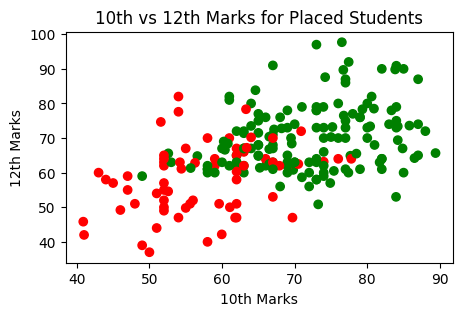

In [232]:
# Scatter plot between 10th and 12th marks
plt.figure(figsize=(5, 3))
plt.scatter(df['ssc_p'], df['hsc_p'], c=df['status'].map({'Placed': 'green', 'Not Placed': 'red'}))
plt.xlabel('10th Marks')
plt.ylabel('12th Marks')
plt.title('10th vs 12th Marks for Placed Students')
plt.show()

Mostly students who got places have, more than 70% of marks in both 10th and 12th standard

**Explanation:**

This markdown cell provides an insight drawn from the scatter plot, suggesting that higher marks in 10th and 12th standards are generally associated with being placed.

**Explanation:**

This code calculates and visualizes the correlation matrix for the numerical columns of the DataFrame `df` using a heatmap from the `seaborn` library. The `annot=True` argument displays the correlation values on the heatmap, helping to understand the relationships between different numerical features.

<Axes: >

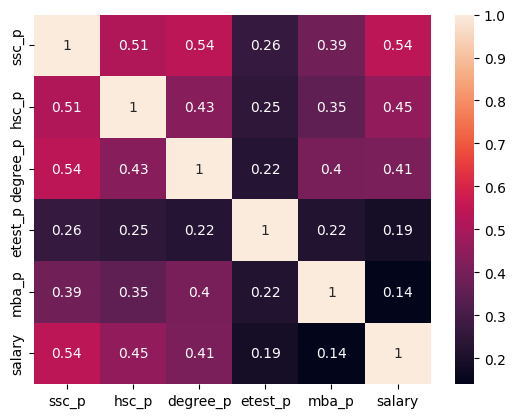

In [233]:
# checking the correlation
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True)

**Explanation:**

This code generates a histogram of the 'salary' column in the DataFrame `df` using `seaborn.histplot`. This visualization helps to understand the distribution of salaries.

<Axes: xlabel='salary', ylabel='Count'>

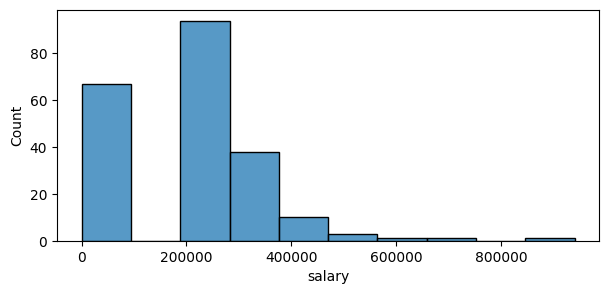

In [234]:
plt.figure(figsize=(7, 3))
sns.histplot(df['salary'])

# **Outlier detection**

**Explanation:**

This markdown cell introduces the section on outlier detection.

**Explanation:**

This code generates a box plot of the 'salary' column for the `df_placed` DataFrame using `seaborn.boxplot`. Box plots are useful for visualizing the distribution of data and identifying potential outliers.

<Axes: ylabel='salary'>

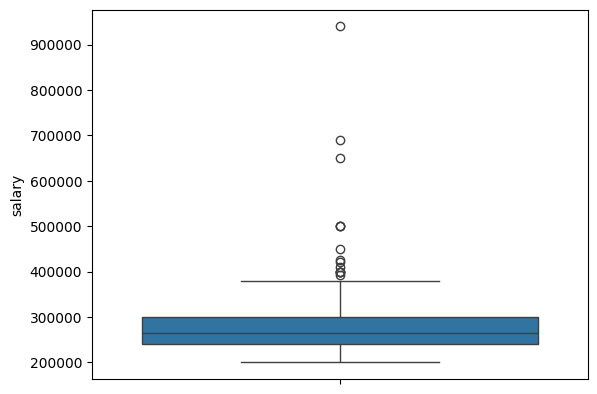

In [235]:
sns.boxplot(df_placed['salary'])

***Using the IQR Method***

**Explanation:**

This markdown cell specifies that the Interquartile Range (IQR) method will be used for outlier detection.

**Explanation:**

This code implements the IQR method to identify and remove outliers in the 'salary' column. It calculates the first quartile (Q1), third quartile (Q3), and the IQR. Then, it determines the lower and upper bounds for outliers and creates a new DataFrame `cleaned_data` that excludes the rows with salaries outside these bounds.

In [236]:
# using IQR Method
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['salary'] < lower_bound) | (df['salary'] > upper_bound)]

cleaned_data = df[(df['salary'] >= lower_bound) & (df['salary'] <= upper_bound)]

**Explanation:**

This code prints the shape of the `cleaned_data` DataFrame after removing outliers. The output `(214, 14)` shows that one row was removed as an outlier.

In [237]:
cleaned_data.shape

(214, 14)

**Explanation:**

This code generates a box plot of the 'salary' column for the `cleaned_data` DataFrame. This box plot shows the distribution of salaries after outlier removal, demonstrating that the extreme value has been handled.

<Axes: ylabel='salary'>

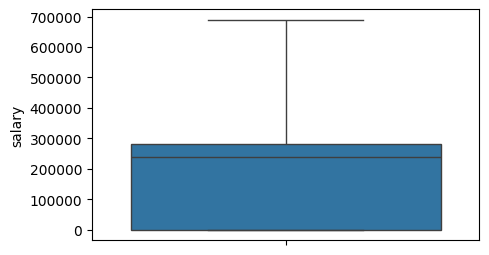

In [238]:
plt.figure(figsize=(5, 3))
sns.boxplot(cleaned_data['salary'])

**Explanation:**

This code displays a random sample of 4 rows from the `cleaned_data` DataFrame. This allows for a quick inspection of the data after outlier removal.

In [239]:
cleaned_data.sample(4)

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
93,M,52.0,Central,62.0,Central,Commerce,54.0,Comm&Mgmt,No,72.00,Mkt&HR,55.41,Not Placed,0.0
157,M,66.5,Central,62.5,Central,Commerce,60.9,Comm&Mgmt,No,93.40,Mkt&Fin,55.03,Placed,300000.0
199,M,69.0,Others,65.0,Others,Commerce,57.0,Comm&Mgmt,No,73.00,Mkt&HR,55.80,Placed,265000.0
34,M,62.0,Others,51.0,Others,Science,52.0,Others,No,68.44,Mkt&HR,62.77,Not Placed,0.0


**Explanation:**

This code prints the information of the `cleaned_data` DataFrame using `.info()`. It shows that the DataFrame now has 214 entries and no missing values in the 'salary' column.

In [240]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214 entries, 0 to 214
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          214 non-null    object 
 1   ssc_p           214 non-null    float64
 2   ssc_b           214 non-null    object 
 3   hsc_p           214 non-null    float64
 4   hsc_b           214 non-null    object 
 5   hsc_s           214 non-null    object 
 6   degree_p        214 non-null    float64
 7   degree_t        214 non-null    object 
 8   workex          214 non-null    object 
 9   etest_p         214 non-null    float64
 10  specialisation  214 non-null    object 
 11  mba_p           214 non-null    float64
 12  status          214 non-null    object 
 13  salary          214 non-null    float64
dtypes: float64(6), object(8)
memory usage: 25.1+ KB


**Explanation:**

This code iterates through the columns of the `cleaned_data` DataFrame. If a column's data type is 'object' (indicating categorical data), it prints the column name and the unique values present in that column. This helps in understanding the different categories within each object type column.

In [241]:
# Checking uniqe in object column
for col in cleaned_data.columns:
    if cleaned_data[col].dtype == 'object':
        print(f"{col}: {cleaned_data[col].unique()}")

gender: ['M' 'F']
ssc_b: ['Others' 'Central']
hsc_b: ['Others' 'Central']
hsc_s: ['Commerce' 'Science' 'Arts']
degree_t: ['Sci&Tech' 'Comm&Mgmt' 'Others']
workex: ['No' 'Yes']
specialisation: ['Mkt&HR' 'Mkt&Fin']
status: ['Placed' 'Not Placed']


Since, we have less number of uniqe in column so will go for Label Encoding

**Explanation:**

This markdown cell explains the decision to use Label Encoding for the categorical columns because they have a relatively small number of unique values.

# **Label Encoding**

**Explanation:**

This markdown cell introduces the Label Encoding section.

**Explanation:**

This code imports the `LabelEncoder` from `sklearn.preprocessing`. It then iterates through the columns of the `cleaned_data` DataFrame. If a column is of 'object' type, it applies Label Encoding to transform the categorical values into numerical labels in-place.

In [242]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in cleaned_data.columns:
    if cleaned_data[col].dtype == 'object':
        cleaned_data[col] = le.fit_transform(cleaned_data[col])

**Explanation:**

This code displays a random sample of 5 rows from the `cleaned_data` DataFrame after applying Label Encoding. This shows that the categorical columns have been converted to numerical representations.

In [243]:
cleaned_data.sample(5)

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
171,1,80.0,1,80.0,1,1,72.0,0,1,63.79,0,66.04,1,290000.0
63,1,61.0,1,70.0,1,1,64.0,0,0,68.50,1,59.50,0,0.0
44,0,77.0,1,73.0,1,1,81.0,0,1,89.00,0,69.70,1,200000.0
147,1,70.0,0,74.0,0,1,65.0,0,0,83.00,0,62.28,1,300000.0
83,1,84.0,1,79.0,1,2,68.0,2,1,84.00,0,66.69,1,300000.0


# **Model Training - Linear Regression**

**Explanation:**

This markdown cell introduces the Model Training section, specifically focusing on Linear Regression.

**Explanation:**

This code imports the necessary libraries for model training: `train_test_split` for splitting data into training and testing sets, `LinearRegression` for building the linear regression model, and `mean_squared_error`, `r2_score` for evaluating the model's performance.

In [244]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

**Explanation:**

This code splits the `cleaned_data` DataFrame into features (`X`) and the target variable (`y`), which is 'salary'. It then further splits `X` and `y` into training and testing sets (`x_train`, `x_test`, `y_train`, `y_test`) using `train_test_split`, with 20% of the data reserved for testing and a `random_state` for reproducibility.

In [245]:
# Splitting the data
X = cleaned_data.drop('salary', axis=1)
y = cleaned_data['salary']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Explanation:**

This code imports `StandardScaler` from `sklearn.preprocessing` and initializes it. It then applies StandardScaler to the training and testing feature sets (`x_train`, `x_test`) to standardize the features by removing the mean and scaling to unit variance. This is often important for linear models.

In [246]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

**Explanation:**

This code initializes a `LinearRegression` model and trains it using the scaled training data (`x_train`, `y_train`) with the `.fit()` method. This is where the model learns the relationship between the features and the target variable.

In [247]:
# model training
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

**Explanation:**

This code uses the trained `model` to make predictions on the scaled test data (`x_test`) using the `.predict()` method. The predictions are stored in the `y_pred` variable.

In [248]:
# Prediction
y_pred = model.predict(x_test)

**Explanation:**

This code evaluates the performance of the Linear Regression model using common regression metrics: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R2). It calculates these metrics using the actual test values (`y_test`) and the predicted values (`y_pred`) and then prints the results.

In [249]:
# Checking the mse, rmse and r2
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Squared Error: 2343200610.181928
Root Mean Squared Error: 48406.61742140147
R-squared: 0.8740998137836391


# **Checking for Overfitting/ Underfitting**

**Explanation:**

This markdown cell introduces the section for checking for overfitting or underfitting of the model.

**Explanation:**

This code calculates the R-squared score for both the training data (`r2_train`) and the testing data (`r2_test`) by making predictions on the respective sets and comparing them to the actual values. It then prints both R-squared scores to assess if the model performs significantly better on the training data (overfitting) or poorly on both (underfitting).

In [250]:
r2_train = r2_score(y_train, model.predict(x_train))
r2_test  = r2_score(y_test, model.predict(x_test))

print("Train R²:", r2_train)
print("Test R²:", r2_test)

Train R²: 0.8229051029420553
Test R²: 0.8740998137836391


*This seems good, model is evenly fitted.*

**Explanation:**

This markdown cell interprets the R-squared scores, suggesting that the model is well-fitted as the training and testing scores are relatively close.

**Explanation:**

This code generates a scatter plot to visualize the relationship between the actual salary values (`y_test`) and the predicted salary values (`y_pred`) from the Linear Regression model. A red dashed line representing a perfect fit is also plotted. This helps to visually assess how well the model's predictions align with the actual values.

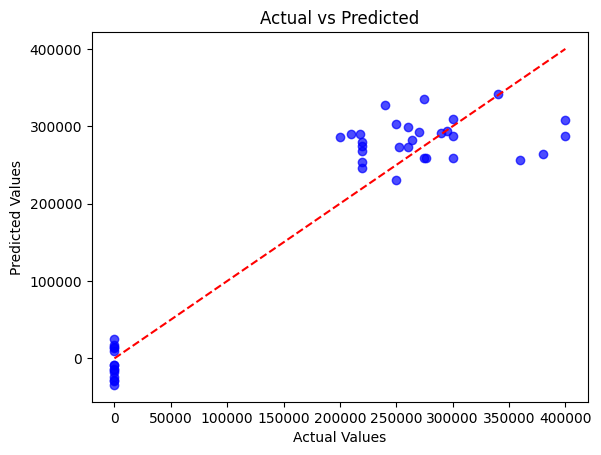

In [251]:
import matplotlib.pyplot as plt

y_pred = model.predict(x_test)

plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linestyle="--")  # perfect fit line
plt.show()

**Explanation:**

This code imports the `joblib` library, which is used for saving and loading Python objects that use NumPy data structures, efficiently. It then saves the trained `model` object to a file named `linear_regression_model.joblib` using `joblib.dump()`. This allows you to persist the trained model for later use without retraining. Finally, it prints a confirmation message indicating where the model was saved.

In [252]:
import joblib

# Save the model to a file
filename = 'linear_regression_model.joblib'
joblib.dump(model, filename)

print(f"Model saved to {filename}")

Model saved to linear_regression_model.joblib


**Explanation:**

This code fills the null values in the 'salary' column of the DataFrame `df` with 0 using the `.fillna(0, inplace=True)` method. This is a way to handle missing values, assuming that a missing salary implies no salary (for unplaced students).

In [190]:
# Fill the null value in salary column with 0
df['salary'].fillna(0, inplace=True)

**Explanation:**

This code counts the occurrences of each unique value in the 'status' column of the DataFrame `df` using the `.value_counts()` method. This shows the distribution of 'Placed' and 'Not Placed' students in the dataset.

In [191]:
# We need to explore the status column
df['status'].value_counts()

,count
status,
Placed,148
Not Placed,67


It can be seen that where even status is not placed, salary is 0

**Explanation:**

This markdown cell observes that students with 'Not Placed' status have a salary of 0, which aligns with the previous data cleaning step.

**Explanation:**

This code checks for duplicate rows in the DataFrame `df` using the `.duplicated().sum()` method. The output of 0 indicates that there are no duplicate rows in the dataset.

In [192]:
# Checking for duplicate values
df.duplicated().sum()

np.int64(0)

Now, this is obvious that Not placed students have no salary. So, let's drop those values right now and work on data only where data exist.

**Explanation:**

This markdown cell indicates the decision to focus the analysis on placed students, as the goal is to understand factors contributing to placement.

# **Analysis of why students placed? and why not?**

**Explanation:**

This markdown cell introduces the section for analyzing the factors influencing student placement.

***Placed Students***

**Explanation:**

This markdown cell specifically focuses on the analysis of students who were placed.

**Explanation:**

This code creates two new DataFrames: `df_placed` containing rows where the 'status' is 'Placed', and `df_unplaced` containing rows where the 'status' is 'Not Placed'. It then displays the first 5 rows of the `df_placed` DataFrame.

In [193]:
df_placed = df[df['status'] == 'Placed']
df_unplaced = df[df['status'] == 'Not Placed']
df_placed.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
7,M,82.00,Central,64.00,Central,Science,66.00,Sci&Tech,Yes,67.0,Mkt&Fin,62.14,Placed,252000.0


**Explanation:**

This code provides descriptive statistics for the numerical columns of the `df_placed` DataFrame. This helps in understanding the characteristics of students who were placed.

In [194]:
df_placed.describe()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000
mean,71.721486,69.926554,68.740541,73.238041,62.579392,288655.405405
std,8.715445,9.329268,6.518087,13.729333,5.884583,93457.452420
min,49.000000,50.830000,56.000000,50.000000,52.380000,200000.000000
25%,65.000000,63.000000,65.000000,60.000000,57.772500,240000.000000
50%,72.500000,68.000000,68.000000,72.000000,62.245000,265000.000000
75%,78.125000,75.250000,72.422500,85.000000,66.760000,300000.000000
max,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


**Explanation:**

This code provides descriptive statistics for the numerical columns of the `df_unplaced` DataFrame. This helps in understanding the characteristics of students who were not placed.

In [195]:
df_unplaced.describe()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,67.000000,67.000000,67.000000,67.000000,67.000000,67.0
mean,57.544030,58.395522,61.134179,69.587910,61.612836,0.0
std,8.394246,9.914090,6.365825,11.930687,5.705689,0.0
min,40.890000,37.000000,50.000000,50.000000,51.210000,0.0
25%,52.000000,51.000000,57.000000,60.000000,58.480000,0.0
50%,56.280000,60.330000,61.000000,67.000000,60.690000,0.0
75%,63.000000,64.000000,65.000000,76.500000,65.405000,0.0
max,77.800000,82.000000,79.000000,97.000000,75.710000,0.0


Insights:

1. Avg. difference betwee ssc marks is: ~15%
2. Avg. difference betwee hsc marks is: ~10%



**Explanation:**

This markdown cell highlights the observed average difference in SSC and HSC marks between placed and unplaced students based on the descriptive statistics.

**Explanation:**

This code generates a scatter plot to visualize the relationship between 10th marks (`ssc_p`) and 12th marks (`hsc_p`). The points are colored based on the 'status' column (green for 'Placed', red for 'Not Placed') to show how these marks relate to placement status.

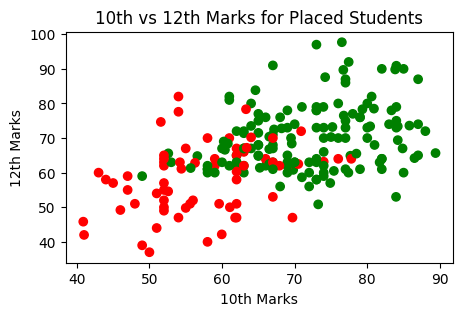

In [196]:
# Scatter plot between 10th and 12th marks
plt.figure(figsize=(5, 3))
plt.scatter(df['ssc_p'], df['hsc_p'], c=df['status'].map({'Placed': 'green', 'Not Placed': 'red'}))
plt.xlabel('10th Marks')
plt.ylabel('12th Marks')
plt.title('10th vs 12th Marks for Placed Students')
plt.show()

Mostly students who got places have, more than 70% of marks in both 10th and 12th standard

**Explanation:**

This markdown cell provides an insight drawn from the scatter plot, suggesting that higher marks in 10th and 12th standards are generally associated with being placed.

**Explanation:**

This code calculates and visualizes the correlation matrix for the numerical columns of the DataFrame `df` using a heatmap from the `seaborn` library. The `annot=True` argument displays the correlation values on the heatmap, helping to understand the relationships between different numerical features.

<Axes: >

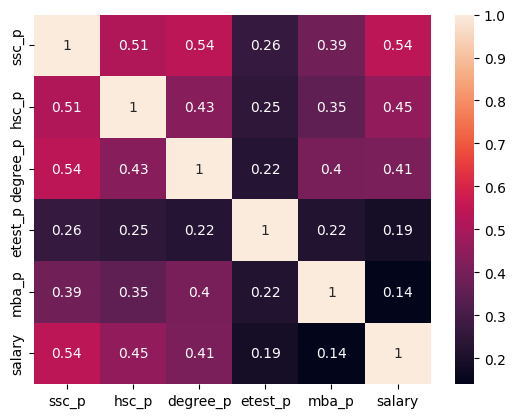

In [197]:
# checking the correlation
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True)

**Explanation:**

This code generates a histogram of the 'salary' column in the DataFrame `df` using `seaborn.histplot`. This visualization helps to understand the distribution of salaries.

<Axes: xlabel='salary', ylabel='Count'>

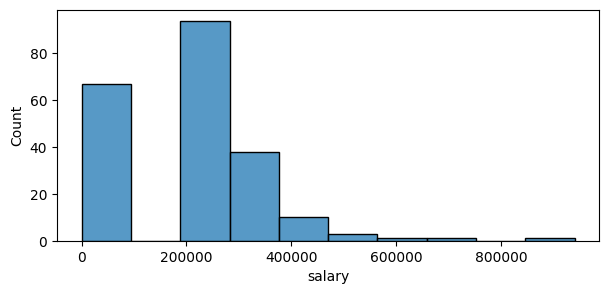

In [198]:
plt.figure(figsize=(7, 3))
sns.histplot(df['salary'])

# **Outlier detection**

**Explanation:**

This markdown cell introduces the section on outlier detection.

**Explanation:**

This code generates a box plot of the 'salary' column for the `df_placed` DataFrame using `seaborn.boxplot`. Box plots are useful for visualizing the distribution of data and identifying potential outliers.

<Axes: ylabel='salary'>

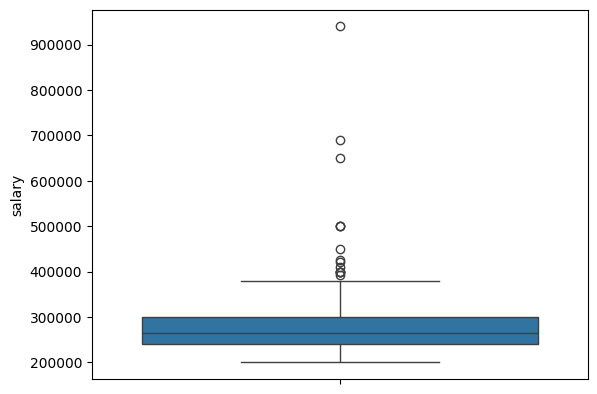

In [199]:
sns.boxplot(df_placed['salary'])

***Using the IQR Method***

**Explanation:**

This markdown cell specifies that the Interquartile Range (IQR) method will be used for outlier detection.

**Explanation:**

This code implements the IQR method to identify and remove outliers in the 'salary' column. It calculates the first quartile (Q1), third quartile (Q3), and the IQR. Then, it determines the lower and upper bounds for outliers and creates a new DataFrame `cleaned_data` that excludes the rows with salaries outside these bounds.

In [200]:
# using IQR Method
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['salary'] < lower_bound) | (df['salary'] > upper_bound)]

cleaned_data = df[(df['salary'] >= lower_bound) & (df['salary'] <= upper_bound)]

**Explanation:**

This code prints the shape of the `cleaned_data` DataFrame after removing outliers. The output `(214, 14)` shows that one row was removed as an outlier.

In [201]:
cleaned_data.shape

(214, 14)

**Explanation:**

This code generates a box plot of the 'salary' column for the `cleaned_data` DataFrame. This box plot shows the distribution of salaries after outlier removal, demonstrating that the extreme value has been handled.

<Axes: ylabel='salary'>

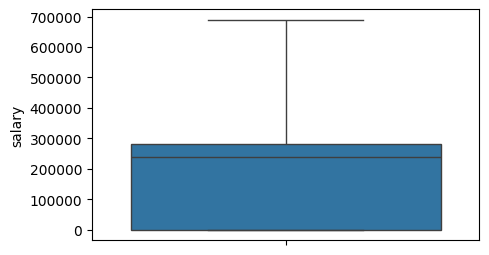

In [202]:
plt.figure(figsize=(5, 3))
sns.boxplot(cleaned_data['salary'])

**Explanation:**

This code displays a random sample of 4 rows from the `cleaned_data` DataFrame. This allows for a quick inspection of the data after outlier removal.

In [203]:
cleaned_data.sample(4)

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
32,F,61.0,Central,81.0,Central,Commerce,66.4,Comm&Mgmt,No,50.89,Mkt&HR,62.21,Placed,278000.0
200,M,69.0,Others,60.0,Others,Commerce,65.0,Comm&Mgmt,No,87.55,Mkt&Fin,52.81,Placed,300000.0
19,M,60.0,Others,67.0,Others,Arts,70.0,Comm&Mgmt,Yes,50.48,Mkt&Fin,77.89,Placed,236000.0
17,F,55.0,Central,67.0,Central,Commerce,64.0,Comm&Mgmt,No,60.00,Mkt&Fin,67.28,Not Placed,0.0


**Explanation:**

This code prints the information of the `cleaned_data` DataFrame using `.info()`. It shows that the DataFrame now has 214 entries and no missing values in the 'salary' column.

In [204]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214 entries, 0 to 214
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          214 non-null    object 
 1   ssc_p           214 non-null    float64
 2   ssc_b           214 non-null    object 
 3   hsc_p           214 non-null    float64
 4   hsc_b           214 non-null    object 
 5   hsc_s           214 non-null    object 
 6   degree_p        214 non-null    float64
 7   degree_t        214 non-null    object 
 8   workex          214 non-null    object 
 9   etest_p         214 non-null    float64
 10  specialisation  214 non-null    object 
 11  mba_p           214 non-null    float64
 12  status          214 non-null    object 
 13  salary          214 non-null    float64
dtypes: float64(6), object(8)
memory usage: 25.1+ KB


**Explanation:**

This code iterates through the columns of the `cleaned_data` DataFrame. If a column's data type is 'object' (indicating categorical data), it prints the column name and the unique values present in that column. This helps in understanding the different categories within each object type column.

In [205]:
# Checking uniqe in object column
for col in cleaned_data.columns:
    if cleaned_data[col].dtype == 'object':
        print(f"{col}: {cleaned_data[col].unique()}")

gender: ['M' 'F']
ssc_b: ['Others' 'Central']
hsc_b: ['Others' 'Central']
hsc_s: ['Commerce' 'Science' 'Arts']
degree_t: ['Sci&Tech' 'Comm&Mgmt' 'Others']
workex: ['No' 'Yes']
specialisation: ['Mkt&HR' 'Mkt&Fin']
status: ['Placed' 'Not Placed']


Since, we have less number of uniqe in column so will go for Label Encoding

**Explanation:**

This markdown cell explains the decision to use Label Encoding for the categorical columns because they have a relatively small number of unique values.

# **Label Encoding**

**Explanation:**

This markdown cell introduces the Label Encoding section.

**Explanation:**

This code imports the `LabelEncoder` from `sklearn.preprocessing`. It then iterates through the columns of the `cleaned_data` DataFrame. If a column is of 'object' type, it applies Label Encoding to transform the categorical values into numerical labels in-place.

In [206]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in cleaned_data.columns:
    if cleaned_data[col].dtype == 'object':
        cleaned_data[col] = le.fit_transform(cleaned_data[col])

**Explanation:**

This code displays a random sample of 5 rows from the `cleaned_data` DataFrame after applying Label Encoding. This shows that the categorical columns have been converted to numerical representations.

In [207]:
cleaned_data.sample(5)

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
62,0,86.50,1,64.2,1,2,67.4,2,0,59.0,0,59.69,1,240000.0
139,1,77.00,0,70.0,0,1,59.0,0,1,58.0,0,54.43,1,220000.0
183,1,65.00,0,77.0,0,1,69.0,0,0,60.0,1,61.82,1,276000.0
25,0,52.58,1,54.6,0,1,50.2,0,1,76.0,0,65.33,0,0.0
172,1,73.00,1,58.0,1,1,56.0,0,0,84.0,1,52.64,1,300000.0


# **Model Training - Linear Regression**

**Explanation:**

This markdown cell introduces the Model Training section, specifically focusing on Linear Regression.

**Explanation:**

This code imports the necessary libraries for model training: `train_test_split` for splitting data into training and testing sets, `LinearRegression` for building the linear regression model, and `mean_squared_error`, `r2_score` for evaluating the model's performance.

In [208]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

**Explanation:**

This code splits the `cleaned_data` DataFrame into features (`X`) and the target variable (`y`), which is 'salary'. It then further splits `X` and `y` into training and testing sets (`x_train`, `x_test`, `y_train`, `y_test`) using `train_test_split`, with 20% of the data reserved for testing and a `random_state` for reproducibility.

In [209]:
# Splitting the data
X = cleaned_data.drop('salary', axis=1)
y = cleaned_data['salary']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Explanation:**

This code imports `StandardScaler` from `sklearn.preprocessing` and initializes it. It then applies StandardScaler to the training and testing feature sets (`x_train`, `x_test`) to standardize the features by removing the mean and scaling to unit variance. This is often important for linear models.

In [210]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

**Explanation:**

This code initializes a `LinearRegression` model and trains it using the scaled training data (`x_train`, `y_train`) with the `.fit()` method. This is where the model learns the relationship between the features and the target variable.

In [211]:
# model training
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

**Explanation:**

This code uses the trained `model` to make predictions on the scaled test data (`x_test`) using the `.predict()` method. The predictions are stored in the `y_pred` variable.

In [212]:
# Prediction
y_pred = model.predict(x_test)

**Explanation:**

This code evaluates the performance of the Linear Regression model using common regression metrics: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R2). It calculates these metrics using the actual test values (`y_test`) and the predicted values (`y_pred`) and then prints the results.

In [213]:
# Checking the mse, rmse and r2
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Squared Error: 2343200610.181928
Root Mean Squared Error: 48406.61742140147
R-squared: 0.8740998137836391


# **Checking for Overfitting/ Underfitting**

**Explanation:**

This markdown cell introduces the section for checking for overfitting or underfitting of the model.

**Explanation:**

This code calculates the R-squared score for both the training data (`r2_train`) and the testing data (`r2_test`) by making predictions on the respective sets and comparing them to the actual values. It then prints both R-squared scores to assess if the model performs significantly better on the training data (overfitting) or poorly on both (underfitting).

In [214]:
r2_train = r2_score(y_train, model.predict(x_train))
r2_test  = r2_score(y_test, model.predict(x_test))

print("Train R²:", r2_train)
print("Test R²:", r2_test)

Train R²: 0.8229051029420553
Test R²: 0.8740998137836391


*This seems good, model is evenly fitted.*

**Explanation:**

This markdown cell interprets the R-squared scores, suggesting that the model is well-fitted as the training and testing scores are relatively close.

**Explanation:**

This code generates a scatter plot to visualize the relationship between the actual salary values (`y_test`) and the predicted salary values (`y_pred`) from the Linear Regression model. A red dashed line representing a perfect fit is also plotted. This helps to visually assess how well the model's predictions align with the actual values.

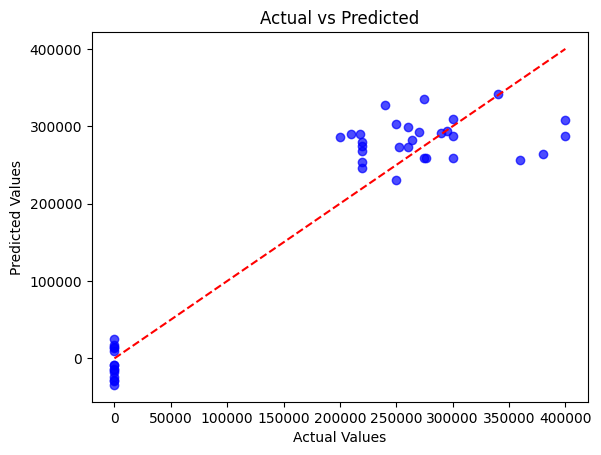

In [215]:
import matplotlib.pyplot as plt

y_pred = model.predict(x_test)

plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linestyle="--")  # perfect fit line
plt.show()

**Explanation:**

This code imports the `joblib` library, which is used for saving and loading Python objects that use NumPy data structures, efficiently. It then saves the trained `model` object to a file named `linear_regression_model.joblib` using `joblib.dump()`. This allows you to persist the trained model for later use without retraining. Finally, it prints a confirmation message indicating where the model was saved.

In [216]:
import joblib

# Save the model to a file
filename = 'linear_regression_model.joblib'
joblib.dump(model, filename)

print(f"Model saved to {filename}")

Model saved to linear_regression_model.joblib
